# Phan mo hinh K - trung binh (K- Means Model) 
## 1.1 Xay dung chuong trinh tu numpy
### Vi du 1. Nhac lai vi du o bai ly thuyet 


- Chúng ta sẽ xét ví dụ nhân tạo với đầu vào là 3 tập ngẫu nhiên, mỗi tập N điểm được khởi tạo theo phân bố
Gaussian (phân bố chuẩn) có 3 kỳ vọng ( tâm cụm) xác định trước là means[1,:], means[2,:] và means[3,:];
có chung ma trận hiệp phương sai là cov[].
- Trong đoạn mã gọi thư viện dưới đây, trước tiên, chúng ta cần numpy và matplotlib như trong các bài trước
cho việc tính toán ma trận và hiển thị dữ liệu. Chúng ta cũng cần thêm thư viện scipy.spatial.distance để tính
khoảng cách giữa các cặp điểm trong hai tập hợp một cách hiệu quả. Sau đó chúng ta tạo dữ liệu theo ý tưởng
ở trên. Đoạn mã lệnh như dưới đây

In [1]:
# Gọi các thư viện cần thiết
# Ta tự xây dựng phần k-means nên sẽ không gọi sklearn
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(11)
# Kỳ vọng và hiệp phương sai của 3 cụm dữ liệu
means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]
# Số điểm mỗi cụm dữ liệu
N = 500
# Tạo các cụm dữ liệu qua phân bố chuẩn (Gaussian)
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)
# Tổng hợp dữ liệu từ các cụm
X = np.concatenate((X0, X1, X2), axis = 0)
# Số cụm = 3
K = 3

# Gán nhãn ban đầu cho các cụm, sau đó ta test model và so sánh
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

- Phương thức để hiển thị dữ liệu X lên mặt phẳng, ở đây sử dụng thông tin nhãn đã được gán ở phần trước
trong tham đối label

In [2]:
def kmeans_display(X, label):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]
    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8)
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8)
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8)
    plt.axis('equal')
    plt.plot()
    plt.show()

- Dưới đây ta sẽ xây dựng một số hàm cần thiết cho mô hình K-means clustering
    - • kmeans_init_centers để khởi tạo các centers ban đầu.
    - • kmeans_asign_labels để gán nhán mới cho các điểm khi biết các centers.
    - • kmeans_update_centers để cập nhật các centers mới dữa trên dữ liệu vừa được gán nhãn.
    - • has_converged để kiểm tra điều kiện dừng của thuật toán.
    Khởi tạo một bộ tâm cụm trên dữ liệu X với giả thiết có k cụm

In [3]:
def kmeans_init_centers(X, k):
    # randomly pick k rows of X as initial centers
    return X[np.random.choice(X.shape[0], k, replace=False)]

- chúng ta chọn các tâm cụm một cách ngẫu nhiên (miễn là các tâm cụm khác nhau). Các bạn hãy thử
điều chỉnh bằng cách chọn K điểm xa nhau nhất theo phương pháp đã được trình bày trong phần lý thuyết.
- Phương thức để gán cụm cho một điểm dữ liệu bằng cách tính khoảng cách từ điểm đó đến các tâm cụm,
khoảng cách đến đâu ngắn nhất thì ta coi điểm hiện tại sẽ thuộc về cụm đó.

In [4]:
def kmeans_assign_labels(X, centers):
    # calculate pairwise distances btw data and centers
    D = cdist(X, centers)
    # return index of the closest center
    return np.argmin(D, axis = 1)

- Phương thức để cập nhật lại tâm cụm sau mỗi bước lặp: Tâm cụm mới sẽ là trung bình cộng (theo tọa độ) của tất cả các điểm có trong cụm)

In [5]:
def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        # collect all points assigned to the k-th cluster
        Xk = X[labels == k, :]
        # take average
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

- Hàm để kiểm tra xem thuật toán có thực sự chạy (có hội tụ hay không) thông qua việc tâm cụm sau mỗi bước
lặp có thay đổi hay không? Nếu tâm cụm không đổi nghĩa là thuật toán đã dừng (hội tụ) – tức là cần trả về
TRUE. Kiểm tra cho tất cả các tâm cụm

In [6]:
def has_converged(centers, new_centers):
    # return True if two sets of centers are the same
    return (set([tuple(a) for a in centers]) ==
    set([tuple(a) for a in new_centers]))

- Vòng lặp để thực hiện tất cả các bước trong thuật toán k-means cho đến khi thuật toán dừng

In [7]:
def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

Centers found by our algorithm:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]


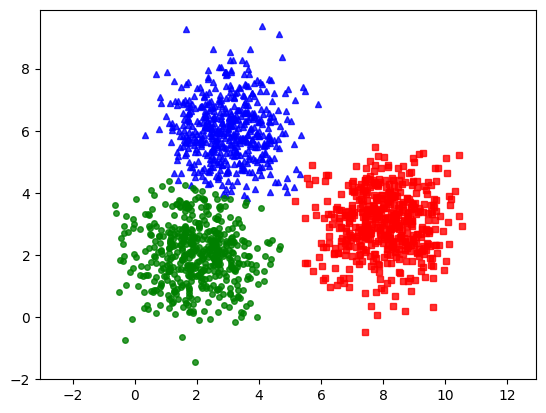

In [8]:
(centers, labels, it) = kmeans(X, K)
print('Centers found by our algorithm:')
print(centers[-1])
kmeans_display(X, labels[-1])

## 1.2 Thuc hien bang thu vien sklearn 

Centers found by scikit-learn:
[[1.97826939 2.00223913]
 [2.98759958 6.02896527]
 [8.0410628  3.02094748]]


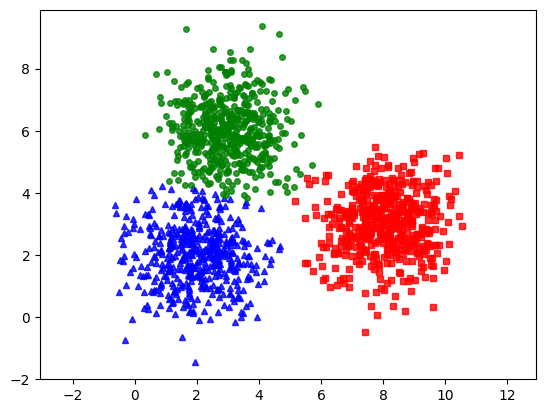

In [9]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
print('Centers found by scikit-learn:')
print(kmeans.cluster_centers_)
pred_label = kmeans.predict(X)
kmeans_display(X, pred_label)

## 1.3 Vi du 2:

Hãy tìm lại phần thực hành đọc dữ liệu từ tệp chứa thông tin hình ảnh các chữ số viết tay và thực hiện việc
phân cụm dữ liệu vào 10 cụm (10 chữ số viết tay) theo cách sau: Đọc 5000 mẫu dữ liệu từ phần training, sau
đó thực hiện phân cụm bằng phương pháp k-means, tiếp theo hãy kiểm tra xem trong mỗi cụm, tỷ lệ có nhãn
nào (từ 0 đến 9) là cao nhất. Sau đó đếm và in ra tỷ lệ các mẫu không thuộc nhãn đó nhưng được phân vào
cùng một cụm với nhãn. Trong phần này ta sẽ sử dụng thư viện

In [10]:
import numpy as np
from mnist import MNIST
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [11]:
# This function visualizes filters in matrix A. Each column of A is a
# filter. We will reshape each column into a square image and visualizes
# on each cell of the visualization panel.
# All other parameters are optional, usually you do not need to worry
# about it.
# opt_normalize: whether we need to normalize the filter so that all of
# them can have similar contrast. Default value is true.
# opt_graycolor: whether we use gray as the heat map. Default is true.
# opt_colmajor: you can switch convention to row major for A. In that
# case, each row of A is a filter. Default value is false.



def display_network(A, m = -1, n = -1):
    opt_normalize = True
    opt_graycolor = True
    # Rescale
    A = A - np.average(A)
    # Compute rows & cols
    (row, col) = A.shape
    sz = int(np.ceil(np.sqrt(row)))
    buf = 1
    if m < 0 or n < 0:
        n = np.ceil(np.sqrt(col))
        m = np.ceil(col / n)
        image = np.ones(shape=(buf + m * (sz + buf), buf + n * (sz + buf)))
    if not opt_graycolor:
        image *= 0.1
    k = 0
    for i in range(int(m)):
        for j in range(int(n)):
            if k >= col:
                continue
            clim = np.max(np.abs(A[:, k]))
            if opt_normalize:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz +
                        buf):buf + j * (sz + buf) + sz] = \
                            A[:, k].reshape(sz, sz) / clim
            else:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz +
                buf):buf + j * (sz + buf) + sz] = \
                A[:, k].reshape(sz, sz) / np.max(np.abs(A))
            k += 1
    return image


def display_color_network(A):
    """
    # display receptive field(s) or basis vector(s) for image patches
    #
    # A the basis, with patches as column vectors
    # In case the midpoint is not set at 0, we shift it dynamically
    :param A:
    :param file:
    :return:
    """
    if np.min(A) >= 0: 
        A = A - np.mean(A)
    cols = np.round(np.sqrt(A.shape[1]))
    channel_size = A.shape[0] / 3
    dim = np.sqrt(channel_size)
    dimp = dim + 1
    rows = np.ceil(A.shape[1] / cols)
    B = A[0:channel_size, :]
    
    C = A[channel_size:2 * channel_size, :]
    D = A[2 * channel_size:3 * channel_size, :]
    B = B / np.max(np.abs(B))
    C = C / np.max(np.abs(C))
    D = D / np.max(np.abs(D))
    
    image = np.ones(shape=(dim * rows + rows - 1, dim * cols + cols - 1, 3))
    for i in range(int(rows)):
        for j in range(int(cols)):
        # This sets the patch
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 0] = B[:, i * cols
            + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 1] = C[:, i * cols
            + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 2] = D[:, i * cols
            + j].reshape(dim, dim)
    image = (image + 1) / 2
    return image

Chạy k-means cho 1000 mẫu dữ liệu đầu tiên

In [12]:
mndata = MNIST('MNIST/')
mndata.load_testing()
X = mndata.test_images
X0 = np.asarray(X)[:1000,:]/256.0
X = X0
K = 10
kmeans = KMeans(n_clusters=K).fit(X)
pred_label = kmeans.predict(X)

/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/.venv/lib/python3.10/site-packages/mnist/loader.py:179: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.return_type is 'lists':
/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/.venv/lib/python3.10/site-packages/mnist/loader.py:181: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif self.return_type is 'numpy':
/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/.venv/lib/python3.10/site-packages/mnist/loader.py:187: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if self.return_type is 'lists':
/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/.venv/lib/python3.10/site-packages/mnist/loader.py:189: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif self.return_type is 'numpy':
/home/datbritget/Documen

FileNotFoundError: [Errno 2] No such file or directory: 'MNIST/t10k-labels-idx1-ubyte'

Chon hien thi mot so anh thuoc mot so cum 

In [ ]:
print(type(kmeans.cluster_centers_.T))
print(kmeans.cluster_centers_.T.shape)
A = display_network(kmeans.cluster_centers_.T, K, 1)
f1 = plt.imshow(A, interpolation='nearest', cmap = "jet")
f1.axes.get_xaxis().set_visible(False)
f1.axes.get_yaxis().set_visible(False)
plt.show()
# plt.savefig('a1.png', bbox_inches='tight')

# a colormap and a normalization instance
cmap = plt.cm.jet
norm = plt.Normalize(vmin=A.min(), vmax=A.max())


# map the normalized data to colors
# image is now RGBA (512x512x4)
image = cmap(norm(A))
import scipy.misc
scipy.misc.imsave('aa.png', image)

In [ ]:
N0 = 20;
X1 = np.zeros((N0*K, 784))
X2 = np.zeros((N0*K, 784))
for k in range(K):
    Xk = X0[pred_label == k, :]
    center_k = [kmeans.cluster_centers_[k]]
    neigh = NearestNeighbors(N0).fit(Xk)
    dist, nearest_id = neigh.kneighbors(center_k, N0)
    X1[N0*k: N0*k + N0,:] = Xk[nearest_id, :]
    X2[N0*k: N0*k + N0,:] = Xk[:N0, :]

In [ ]:
plt.axis('off')
A = display_network(X2.T, K, N0)
f2 = plt.imshow(A, interpolation='nearest' )
plt.gray()
plt.show()

## Bai tap thuc hanh 

### Bai 1.1: 
Hãy áp dụng đoạn chương trình chúng ta tự xây dựng trong ví dụ 1, với dữ liệu là hình ảnh chữ số
viết tay như trong ví dụ 2, chạy để xem xét kết quả

### Bai 1.2: 
Áp dụng mô hình trên cho bài tập phân loại ảnh chó-mèo (xem lại phần CNN), thử thực hiện phân
cụm thành 02 cụm và kiểm tra kết quả.

# Mo hinh DBSCAN

## Vi du 2.1: 